<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re

In [ ]:
pd.set_option('display.max_rows',None)      # shows all the rows when the df is printed
pd.set_option('display.max_columns',None)   # shows all the coulumns when the df is printed
pd.set_option('display.max_colwidth',None)  # shows the complete column

In [ ]:
df = pd.read_csv('/content/gurgaon_properties_cleaned_v1 (1).csv')

In [ ]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,not available,2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall Sohna', 'Omaxe Gurgaon Mall', 'Badshahpur Sohna Rd Hwy', 'Vidya Niketan School', 'KIIT College of Engg', 'Scottish High International School', 'Rawal Institutions', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Spaze Business Park', 'DLF Cyber City']",NaN,"['Lift(s)', 'Park']"


In [ ]:
df.duplicated().sum()

np.int64(122)

In [ ]:
df.iloc[973]

,973
property_type,house
society,independent
sector,sector 36
price,0.75
price_per_sqft,6938.0
area,1081.0
areaWithType,Built Up area: 1081 (100.43 sq.m.)
bedRoom,3
bathroom,1
balcony,0


## AreaWithType

In [ ]:
# split the areawithtype column into 3 separate columns like : superbuiltup area , builtup area and carpet area for flats unit-->sqft

In [ ]:
df.loc[:10,['area','areaWithType']]

,area,areaWithType
0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.)
1,1105.0,Carpet area: 1103 (102.47 sq.m.)
2,58228.0,Carpet area: 58141 (5401.48 sq.m.)
3,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.)
4,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.)
5,532.0,Super Built up area 632(58.71 sq.m.)Carpet area: 532 sq.ft. (49.42 sq.m.)
6,5350.0,Super Built up area 5350(497.03 sq.m.)
7,2338.0,Super Built up area 2338(217.21 sq.m.)
8,2087.0,Super Built up area 1889(175.49 sq.m.)
9,1186.0,Plot area 1185.51(110.14 sq.m.)


In [ ]:
def get_super_built_up_area(text):    # get the superbuiltup area from the areaWithType column given in the data
  match = re.search(r'Super Built up area (\d+\.?\d*)',text)    # in the text search for the phrase "super build up area" and the number ahead of it
  if match:
    return float(match.group(1))          # get the number ahead of the phrase, convert  to float and return it
  return None


def convert_to_sqft(text,area_value):                 # text = areawithtype column  , area_value = a row of the column 'super built up area' , 'built up area' or the 'carpet area' its a number
  if area_value is None:
    return None
  match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value),text)   # in the text we search for the bracket in which a number and sq.m. is written
  if match:
    sq_m_value = float(match.group(1))                # we get that number before sq.m.
    return sq_m_value * 10.7639                       # multiply it by 10.7 to make it square feet and then return it
  return area_value                                   # else we directly return the number as it is alread in the square feet

df['super_builtup_area'] = df['areaWithType'].apply(get_super_built_up_area)
converted_super_builtup = []
for area in range(len(df)):
  text = df.loc[area,'areaWithType']
  area_value = df.loc[area,'super_builtup_area']
  converted_super_builtup.append(convert_to_sqft(text,area_value))
df['super_builtup_area'] = converted_super_builtup

In [ ]:
def get_area(text,area_type):                               # text = each rows in the areaType column and  areatype will be buildup area or the carpet area
  match = re.search(area_type+ r'\s*:\s*(\d+\.?\d*)',text)   # look after the areatype and the number after the colon
  if match:
    return float(match.group(1))                          #return the number after the colon and the area type
  return None

get_builtuparea = []
for area in range(len(df)):
  text = df.loc[area ,'areaWithType']
  area_type = 'Built Up area'
  get_builtuparea.append(get_area(text , area_type))
df['builtup_area'] = get_builtuparea

converted_builtup = []
for area in range(len(df)):
  text = df.loc[area,'areaWithType']
  area_value = df.loc[area,'builtup_area']
  converted_builtup.append(convert_to_sqft(text,area_value))
df['builtup_area'] = converted_builtup

In [ ]:
get_carpetarea = []
for area in range(len(df)):
  text = df.loc[area ,'areaWithType']
  area_type = 'Carpet area'
  get_carpetarea.append(get_area(text , area_type))
df['carpet_area'] = get_carpetarea

converted_carpet=[]
for area in range(len(df)):
  text = df.loc[area,'areaWithType']
  area_value = df.loc[area,'carpet_area']
  converted_carpet.append(convert_to_sqft(text,area_value))
df['carpet_area'] = converted_carpet

In [ ]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area
564,house,unitech nirvana birch court,sector 50,11.95,36883.0,3240.0,Plot area 360(301.01 sq.m.),3,3,2,"study room,servant room",1.0,West,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Standard chartered ATM', 'Icici bank ATM', 'Vatsalya Clinic', 'Bones Clinic - Orthopaedics', 'Meher Clinic', 'Dr. Naresh Pandita', 'Vishesh Dental', 'Park Hospital Gurgaon', 'Dr. Anuj Sharma', 'Neelkanth Health Care', 'Skin Clinic', 'Divine Look Clinic Centre', 'Dr. Aruna Kalra', 'Wellness Eye Centre', 'Best Urologist Atcomplete Family Clinic', 'Sukhmani Hospital Pvt. Ltd', 'Wembley estate club', 'Gardian Pharmacy', 'Genius', 'Apollo Pharmacy', 'SPAZE BUSINESS PARK', 'Unitech', 'Hdfc bank', 'Hdfc bank', 'Hdfc bank', 'Icici bank', 'Indusind bank', 'Hdfc bank and atm', 'SRS Cinemas', 'Madison and Pike', 'India', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Starbucks', 'Nook', 'Pizza Hut', 'Kamla International', 'Gurugram University', 'Amity Global School', 'Delhi Public School Primary Section', 'Manav Rachna School', 'Manav Rachna Swimming Pool']","['1 Wardrobe', '1 Fan', '1 Geyser', '3 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,NaN,NaN
1375,house,ansals palam vihar,sector 2,5.70,14729.0,3870.0,Plot area 430(359.53 sq.m.)Built Up area: 4550 sq.yards (3804.38 sq.m.)Carpet area: 4450 sq.yards (3720.77 sq.m.),5,5,2,pooja room,2.0,North-East,10+ Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'HUDA Sector 23 Market', 'Ram Mandir', 'Kalyan Hospital Gurgaon', ""DR KAPOOR'S Dental Care and Implant Centre"", 'Metro Hospital and Heart Institute Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Jiya Clinic', 'Dr. Mittal Clinic', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Yashroop Medical Centre', 'Ansals plaza underground car parking', 'Ansals Plaza above ground car parking', 'HUDA sector 23 parking', 'Axis bank', 'Punjab national bank', 'Big Cinemas', ""McDonald's"", 'Moti Mahal', 'Pind Baluchi', 'Cafe Coffee Day', 'Pizza Hut', ""Domino's Pizza"", 'Om Sweets', 'Chiranjiv Bharati School', 'Masti ki Pathshala Teach India', 'THE NORTHCAP UNIVERSITY', 'Swiss Cottage school', 'Palam vihar railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Water Purifier', '8 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '1 Stove', '40 Light', '1 Chimney', '1 Modular Kitchen', '1 Curtains', '5 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No AC', 'No Bed', 'No TV']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Waste Disposal', 'Rain Water Harvesting']",NaN,4550.0,4450.0
2096,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,servant room,4.0,NaN,0 to 1 Year Old,"['Sikandarpur metro station', 'Sikanderpur metro station', 'Sikandarpur rmrg metro station', 'Dlf phase 1 metro station', 'Dlf phase 2 metro station', 'Guru dronacharya metro station', 'Mg road 

In [ ]:
print(df.duplicated().sum())

122


In [ ]:
# get the number of flats where all 3 values are given
df[~((df['super_builtup_area'].isnull())|(df['builtup_area'].isnull())|(df['carpet_area'].isnull()))].shape

(534, 20)

In [ ]:
# we have 534 properties out of 3800 where all three areas are given

In [ ]:
# extract rows having plot area
df[df['areaWithType'].str.contains('Plot area')].shape

(682, 20)

In [ ]:
# 682 houses have the plot ara given

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       3803 non-null   object 
 1   society             3802 non-null   object 
 2   sector              3803 non-null   object 
 3   price               3785 non-null   float64
 4   price_per_sqft      3785 non-null   float64
 5   area                3785 non-null   float64
 6   areaWithType        3803 non-null   object 
 7   bedRoom             3803 non-null   int64  
 8   bathroom            3803 non-null   int64  
 9   balcony             3803 non-null   object 
 10  additionalRoom      3803 non-null   object 
 11  floorNum            3784 non-null   float64
 12  facing              2698 non-null   object 
 13  agePossession       3802 non-null   object 
 14  nearbyLocations     3626 non-null   object 
 15  furnishDetails      2822 non-null   object 
 16  featur

In [ ]:
df.shape

(3803, 20)

In [ ]:
print("number of missing values in superbuiltuparea : ",df.shape[0] - df['super_builtup_area'].notna().sum())
print("number of missing values in builtuparea : ",df.shape[0] - df['builtup_area'].notna().sum())
print("number of missing values in carpetarea : ",df.shape[0] - df['carpet_area'].notna().sum())

number of missing values in superbuiltuparea :  1888
number of missing values in builtuparea :  2616
number of missing values in carpetarea :  1859


In [ ]:
# make dataframe of those rows where all 3 (super built up , built up and carpet) are null values
all_nan_df = df[((df['super_builtup_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_builtup_area','builtup_area','carpet_area']]

In [ ]:
all_nan_df.sample(10)

# thus the property_type for the rows where superbuiltup , builtup and carpetarea is null is house and thus the areatype is always the plot area

,price,property_type,area,areaWithType,super_builtup_area,builtup_area,carpet_area
3565,0.38,house,900.0,Plot area 900(83.61 sq.m.),NaN,NaN,NaN
790,4.50,house,2880.0,Plot area 320(267.56 sq.m.),NaN,NaN,NaN
3069,0.27,house,225.0,Plot area 225(20.9 sq.m.),NaN,NaN,NaN
392,6.50,house,2500.0,Plot area 2500(232.26 sq.m.),NaN,NaN,NaN
852,0.95,house,1065.0,Plot area 1065(98.94 sq.m.),NaN,NaN,NaN
2312,0.29,house,891.0,Plot area 891(82.78 sq.m.),NaN,NaN,NaN
1259,7.25,house,360.0,Plot area 360(33.45 sq.m.),NaN,NaN,NaN
975,6.75,house,232.0,Plot area 232(21.55 sq.m.),NaN,NaN,NaN
2085,8.50,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
2292,5.51,house,3243.0,Plot area 361(301.84 sq.m.),NaN,NaN,NaN


In [ ]:
all_nan_df['property_type'].value_counts()

,count
property_type,
house,546


In [ ]:
all_nan_df.isnull().sum()

,0
price,12
property_type,0
area,12
areaWithType,0
super_builtup_area,546
builtup_area,546
carpet_area,546


In [ ]:
all_nan_df[all_nan_df['area'].isnull()]

,price,property_type,area,areaWithType,super_builtup_area,builtup_area,carpet_area
38,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
304,NaN,house,NaN,Plot area 670(560.21 sq.m.),NaN,NaN,NaN
401,NaN,house,NaN,Plot area 1000(92.9 sq.m.),NaN,NaN,NaN
813,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
922,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
1419,NaN,house,NaN,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
2139,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
2943,NaN,house,NaN,Plot area 2700(250.84 sq.m.),NaN,NaN,NaN
3009,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
3038,NaN,house,NaN,Plot area 270(225.75 sq.m.),NaN,NaN,NaN


In [ ]:
# also store the index of sunch rows
all_nan_indices = df[((df['area'].isnull()) &(df['super_builtup_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull()))].index

In [ ]:
# extract the plot area from the new df and add those values to the original data frame under the buildup area column
# but the area column in the new data frame is equal to the plot area in square feet , thus we can replace it directly in the buildup area of the original dataframe

In [ ]:
condition = (
    df['super_builtup_area'].isnull() &
    df['builtup_area'].isnull() &
    df['carpet_area'].isnull()
)

df.loc[condition, 'builtup_area'] = df.loc[condition, 'area']

# fill the built up area with the values of the area column

In [ ]:
all_nan_indices

# but there are some rows where area column also has null values , if we see such cases , we see that the number given in the area with type column is in squae yards

Index([38, 304, 401, 813, 922, 1419, 2139, 2943, 3009, 3038, 3464, 3482], dtype='int64')

In [ ]:
# thus fill the builtarea of those rows manually where the area is not given and area type is in square yards

df.loc[38, 'builtup_area'] = 3150
df.loc[304, 'builtup_area'] = 6030
df.loc[401, 'builtup_area'] = 1000
df.loc[813, 'builtup_area'] = 2160
df.loc[922, 'builtup_area'] = 3150
df.loc[1419,'builtup_area'] = 4518
df.loc[2139,'builtup_area'] = 4680
df.loc[2943,'builtup_area'] = 2700
df.loc[3009,'builtup_area'] = 4680
df.loc[3038,'builtup_area'] = 2430
df.loc[3464,'builtup_area'] = 4500
df.loc[3482,'builtup_area'] = 3240

In [ ]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,not available,2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall Sohna', 'Omaxe Gurgaon Mall', 'Badshahpur Sohna Rd Hwy', 'Vidya Niketan School', 'KIIT College of Engg', 'Scottish High International School', 'Rawal Institutions', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Spaze Business Park', 'DLF Cyber City']",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,Within 6 months,"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,1103.0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road', 'Dwarka Expy', 'RPS International School', 'SGT University', 'Shree Radhey Hospital And Trauma Center', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,not available,17.0,NaN,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,1000.0,585.0
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,"servant room,others",10.0,North-West,1 to 5 Year Old,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-8, Imt Manesar', 'Western Peripheral Expressway', 'RPS International School Sector 89', 'DPG Institute of Technology', 'Aarvy Healthcare Hospital', 'Indira Gandhi International Airport', 'Holiday Inn Sector 90', 'De Adventure Park', 'National Tennis Academy Sector 98']","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '15 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 

## Additional Room

In [ ]:
print(df['additionalRoom'].value_counts())

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [ ]:
print(df['additionalRoom'].dropna().unique())

['not available' 'study room,servant room' 'servant room,others'
 'store room' 'pooja room,servant room,others' 'servant room' 'pooja room'
 'others' 'store room,pooja room,servant room'
 'pooja room,study room,servant room,store room' 'servant room,store room'
 'study room' 'pooja room,others' 'study room,store room'
 'pooja room,study room,servant room,others'
 'study room,pooja room,store room' 'pooja room,study room,servant room'
 'pooja room,store room,study room,servant room'
 'pooja room,servant room,study room,store room' 'pooja room,servant room'
 'study room,pooja room,servant room'
 'servant room,pooja room,store room,study room' 'servant room,pooja room'
 'servant room,study room' 'servant room,study room,pooja room'
 'study room,others' 'store room,pooja room'
 'study room,servant room,pooja room,store room' 'others,study room'
 'pooja room,study room' 'others,servant room'
 'store room,servant room,study room,pooja room' 'store room,servant room'
 'pooja room,servant room

In [ ]:
# make 5 columns of the room type 1) study room 2) pooja rooom 3)store room 4) servant room 5) others

new_cols = ['study room','servant room','store room','pooja room','others']     # list containing names of the new columns to be added as new columns in the df
for col in new_cols:
  df[col]=df['additionalRoom'].str.contains(col).astype(int)    # search for the col_name in the additionalroom column , if it contains the col name .astype returns 1 indicating true else returns 0 indicationg false

In [ ]:
df.sample(5)[['study room','servant room','store room','pooja room','others']]

,study room,servant room,store room,pooja room,others
2261,0,0,0,0,0
3672,1,0,0,0,0
1798,0,0,1,1,0
3048,0,0,0,0,0
2275,1,1,1,1,0


# age_possesion

In [ ]:
# age possession
print(df['agePossession'].value_counts())

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Dec 2025                 7
Aug 2023                 7
Jun 2024                 7
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Aug 2024                 4
Jul 2024                 4
Sep 2023                 4
Feb 2024                 3
Jan 2025                 3
Nov 2024                 3
May 2024                 3
Jun 2027                 2
Jan 2026                 2
Jul 2027                 2
Aug 2025                 2
Jul 2025                 2
Oct 2025                 2
Dec 2026                 2
Apr 2026                 2
By 2027       

In [ ]:
 # make categories on the basis of the date/age of the house given
def seg_age_of_house(value):
  if pd.isna(value):
    return "undefined"
  elif "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
    return "New Property"
  elif "1 to 5 Year Old" in value:
    return "Relatively New"
  elif "5 to 10 Year Old" in value:
    return "Moderately Old"
  elif "10+ Year Old" in value:
    return "Old Property"
  elif "Under Construction" in value or "by" in value:
    return "Under Construction"
  try :
    int(value.split(" ")[-1])
    return "Under Construction"
  except:
    return "undefined"

In [ ]:
df['agePossession'] = df['agePossession'].apply(seg_age_of_house)

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,not available,2.0,NaN,New Property,"['Sector 55-56 Metro Station', 'The Leaf Mall Sohna', 'Omaxe Gurgaon Mall', 'Badshahpur Sohna Rd Hwy', 'Vidya Niketan School', 'KIIT College of Engg', 'Scottish High International School', 'Rawal Institutions', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Spaze Business Park', 'DLF Cyber City']",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,New Property,"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,1103.0,1,1,0,0,0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road', 'Dwarka Expy', 'RPS International School', 'SGT University', 'Shree Radhey Hospital And Trauma Center', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,not available,17.0,NaN,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,1000.0,585.0,0,0,0,0,0
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,"servant room,others",10.0,North-West,Relatively New,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-8, Imt Manesar', 'Western Peripheral Expressway', 'RPS International School Sector 89', 'DPG Institute of Technology', 'Aarvy Healthcare Hospital', 'Indira Gandhi International Airport', 'Holiday Inn Sector 90', 'De Adventure Park', 'National Tennis Academy Sector 98']","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '15 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Wate

## Furnish Details

In [ ]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1736,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
337,NaN,"['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Waste Disposal', 'Rain Water Harvesting']"
3417,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
3584,"['5 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
3633,NaN,NaN


In [ ]:
# cannot identify the condition of the house just by looking at furnishDetails , thus when we have a large number of columns and not able to identify the ways in which
# the columns can be divided we use clustering

In [ ]:
df['furnishDetails'].isnull().sum()

np.int64(981)

In [ ]:
df['furnishDetails'].value_counts().shape     # we have 1804 different combinations of furishing goods

(1804,)

In [ ]:
all_furnishing = []           # list to store all the furishinig goods
for detail in df['furnishDetails'].dropna():       # iterate over the column furnishDetails
  cleaned = detail.replace('[','').replace(']','').replace("'","").split(', ')     # remove the '[',']' and "," and split the text on ,
  all_furnishing.extend(cleaned)    # keep oon adding the elements in the list
unique_furnishings = list(set(all_furnishing))    # make a set to store only the unique items

In [ ]:
# just count the number of times each fuurnishing good has occured in each row of the furnish details column

def get_furnishing_count(details , furnishing):   # detail = each row in the details column  , furishing = name of the furisher good
  if isinstance(details , str):                   # check if the details belong to the string class i.e check if details is a string
    if f"No {furnishing}" in details:             # if the phrase "no {name of the furnishing good, eg ac , tv }" does not exist in the current detail
      return 0                                    # write 0 for that furnishing item in the new data frame
    pattern = re.compile(f"(\d+) {furnishing}")    # get the number before the furnishing good , for 2 beds , get 2
    match = pattern.search(details)    # match is the count of good and the name , eg- 2 beds
    if match:                          # if it exists in the given detail
      return int(match.group(1))       # add the number in the furishing for that detail
    elif furnishing in details:        # if number is not givem and the item exist in the row
      return 1
  return 0

# we create a list of columns which will have the names of the furnishing goods , this list will be created by removing the prefixes like "no" or any number from the
# unique_furnishings columns

furnishing_items = []     # create a list to store the names of the furnishing goods
for item in unique_furnishings:
  cleaned_name = re.sub(r'No\s+|\d+','',item).strip()      # remove the prefix of every item
  if cleaned_name !='' and cleaned_name not in furnishing_items:
    furnishing_items.append(cleaned_name)


for item in furnishing_items:
  counts = []
  for detail in df['furnishDetails']:
    count = get_furnishing_count(detail , item)
    counts.append(count)
  df[item] = counts

furnishings_df = df[['furnishDetails']+furnishing_items]

In [ ]:
furnishings_df.head()

,furnishDetails,Geyser,Bed,Light,Wardrobe,Curtains,Fan,AC,Water Purifier,Chimney,Microwave,Sofa,Stove,Modular Kitchen,TV,Washing Machine,Fridge,Dining Table,Exhaust Fan
0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '15 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",3,0,15,3,4,6,5,0,1,0,0,0,1,0,0,0,0,1


In [ ]:
furnishings_df.iloc[3031]

,3031
furnishDetails,"['4 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '14 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']"
Geyser,4
Bed,0
Light,14
Wardrobe,4
Curtains,0
Fan,6
AC,0
Water Purifier,1
Chimney,1


In [ ]:
furnishings_df.shape

(3803, 19)

In [ ]:
furnishings_df.isnull().sum()

,0
furnishDetails,981
Geyser,0
Bed,0
Light,0
Wardrobe,0
Curtains,0
Fan,0
AC,0
Water Purifier,0
Chimney,0


In [ ]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipython-input-723-114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# while clustering make sure that the NaN values in the furnishDetails will be assigned to the 0 cluster
nan_mask  = df['furnishDetails'].isna().values       # storees true for the cases where NaN is there in furnishDetails in the nnull value column
furnishings_df = furnishings_df.fillna(0)         # for the null values , each column will be filled with 0

scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

wcss_reduced = []       # array to store the within cluster sum of squares , smaller this value is , points are near to the centroid
for i in range (1,11):        # number of clusters to make = i
  kmeans = KMeans(n_clusters=i , init='k-means++' , random_state=42)
  kmeans.fit(scaled_data)
  wcss_reduced.append(kmeans.inertia_)

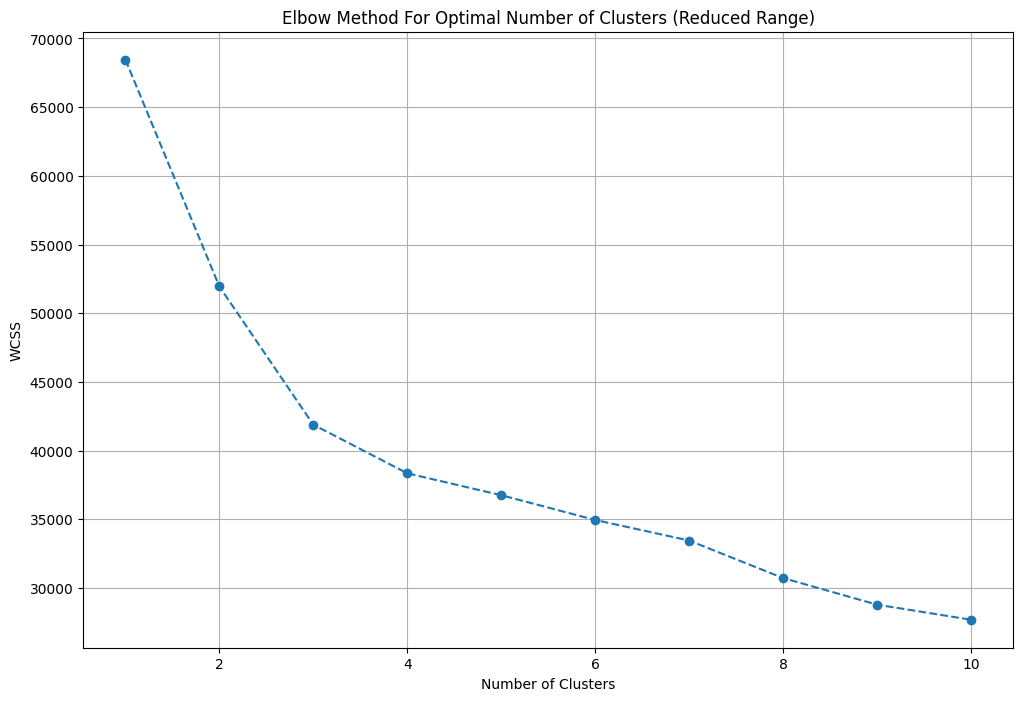

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


# plot the wcss aka intertia , one where the graph flattens is the best

## elbow point : k = 3


## thus data can be divided into 3 categories : furnished , semifurnished and unfurnished

In [ ]:
n_clusters = 3
kmeans = KMeans(n_clusters=3 , random_state=42)
kmeans.fit(scaled_data)
cluster_assignment = kmeans.predict(scaled_data)
cluster_assignment[nan_mask] = 0

In [ ]:
df = df.iloc[:,:-18]

In [ ]:
df['furnishing_type'] = cluster_assignment

In [ ]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
1,1553
0,1193
2,1057


In [ ]:
df.sample(5)[['furnishDetails' , 'furnishing_type']]

,furnishDetails,furnishing_type
758,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
449,"['4 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Geyser', '14 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
2916,NaN,0
3292,"['7 Wardrobe', '15 Fan', '1 Exhaust Fan', '55 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
2651,NaN,0


## features

In [ ]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
22,flat,m3m woodshire,sector 107,0.90,6590.0,1366.0,Super Built up area 1366(126.91 sq.m.),2,2,3+,others,10.0,NaN,Relatively New,"['Signum 107', 'Nora Solomon Medicenter', 'Indira Gandhi International Airport', 'The Shikshiyan School', 'Najafgarh Jheel Bird Sanctuary', 'Skylark Cricket Academy']","['1 Water Purifier', '5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '12 Light', '4 AC', '1 Chimney', '1 Modular Kitchen', '1 TV', '2 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Washing Machine']",NaN,1366.0,NaN,NaN,0,0,0,0,1,2
652,flat,bestech altura,sector 79,1.90,9000.0,2111.0,Carpet area: 2150 (199.74 sq.m.),3,4,2,servant room,11.0,NaN,New Property,"['Sapphire 83 Mall', 'NH -8', 'Golf Course Extension Road', 'Mount Olympus Junior School', 'Amity University Gurugram', 'Miracles Apollo Hospital', 'Indira Gandhi International Airport', 'IMT Manesar', 'Savoy Suites, Manesar', 'Golden Greens Golf & Resorts']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,2150.0,0,1,0,0,0,1
1658,flat,smart world gems,sector 89,1.05,9519.0,1103.0,Built Up area: 1103 (102.47 sq.m.),2,2,2,"study room,others",4.0,NaN,Under Construction,"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,1103.0,NaN,1,0,0,0,1,0
2136,flat,tarc maceo,sector 91,1.90,6975.0,2724.0,Super Built up area 2724(253.07 sq.m.),4,4,3,servant room,9.0,North,Relatively New,"['Manish Gallexie 91', 'Dwarka Expressway', 'Rao Bharat Singh International School', 'Dronacharya College of Engineering', 'Silver Streak Multi Speciality Hospital', 'Indira Gandhi International Airport', 'IMT Manesar', 'Holiday Inn Sector 90', 'Manesar Golf Course', 'National Tennis Academy']",NaN,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",2724.0,NaN,NaN,0,1,0,0,0,0
2829,house,independent,sector 26,16.00,35556.0,4500.0,Plot area 500(418.06 sq.m.),5,6,3,not available,2.0,North-East,Old Property,"['Guru dronacharya metro station', 'Dlf phase 1 metro station', 'Sikandarpur rmrg metro station', 'Sikanderpur metro station', 'Sikandarpur metro station', 'Dlf phase 2 metro station', 'Hanuman Mandir', 'Icici bank ATM', 'Axis bank ATM', 'Central bank ATM', 'Central bank atm teste 001112', 'Sikka Maternity And Surgical Center', 'Anahat Hospital', 'Divine Look Clinic Centre 1', 'The Dental Lounge', ""St Stephen's Hospital Health Care Facility"", 'Marwah Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Upkar Clinic', 'Surgi Center Clinic', 'Lord Krishna Hospital', 'Uma Sanjeevani Health Centre And Hospital', 'Cosmodentz Dental Clinic', 'Kailash Nursing Home Gurgaon', ""Dr. Khullar's Dental Clinic"", 'Relief Physiotherapy Clinic', 'RBS Dental Clinic', 'Sidhesh Hospital Gurgaon', 'Shri Ram Me

In [ ]:
print("null values : ",df.features.isnull().sum())

null values :  635


In [ ]:
# fill these null values with the topFacilites column from the apartment data for the same society

apt_df  = pd.read_csv('/content/apartments.csv')

In [ ]:
df['society'].head()

,society
0,signature global park 4
1,smart world gems
2,pyramid elite
3,breez global hill view
4,bestech park view sanskruti


In [ ]:
apt_df['PropertyName'] = apt_df['PropertyName'].str.lower() # convert the society name to lower case

In [ ]:
df[['society','features']].head()

,society,features
0,signature global park 4,"['Lift(s)', 'Park']"
1,smart world gems,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']"
2,pyramid elite,"['Intercom Facility', 'Lift(s)', 'Park']"
3,breez global hill view,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
4,bestech park view sanskruti,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [ ]:
apt_df[['PropertyName','TopFacilities']].head()

,PropertyName,TopFacilities
0,smartworld one dxp,"['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,m3m crown,"['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"
2,adani brahma samsara vilasa,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amphitheatre', 'Party Lawn', 'Basketball Court', 'Badminton Court', 'Yoga/Meditation Area', 'Indoor Games']"
3,sobha city,"['Swimming Pool', 'Volley Ball Court', 'Aerobics Centre', 'Card Room', 'Barbecue', 'Sauna', 'Steam Room', 'Creche/Day care', 'Skating Rink']"
4,signature global city 93,"['Mini Theatre', 'Doctor on Call', 'Concierge Service', 'Swimming Pool', 'Bar/Chill-Out Lounge', 'Laundry', 'Flower Garden', 'Reflexology Park', 'Salon']"


In [ ]:
df[['society','features']].isnull().sum()

,0
society,1
features,635


In [ ]:
apt_df[['PropertyName','TopFacilities']].isnull().sum()

,0
PropertyName,0
TopFacilities,0


In [ ]:
# for the 635 features which are missing we would use the TopFacilities to fill them

# extract such rows from the dataframe where feature is null

null_amenities = df[df['features'].isnull()]

In [ ]:
apt_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,smartworld one dxp,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,m3m crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"
2,adani brahma samsara vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63, Gurgaon","['AIPL Business Club Sector 62', 'Heritage Xperiential Learning School', 'CK Birla Hospital', 'Paras Trinity Mall Sector 63', 'Rapid Metro Station Sector 56']","{'AIPL Business Club Sector 62': '2.7 Km', 'Heritage Xperiential Learning School': '2 Km', 'CK Birla Hospital': '2.5 Km', 'Paras Trinity Mall Sector 63': '3.5 Km', 'Rapid Metro Station Sector 56': '3.8 Km', 'De Adventure Park': '6.8 Km', 'Golf Course Ext Rd': '99 Meter', 'DoubleTree by Hilton Hotel Gurgaon': '3.6 Km', 'KIIT College of Engineering Sohna Road': '8.4 Km', 'Mehrauli-Gurgaon Road': '11.8 Km', 'Indira Gandhi International Airport': '21.1 Km', 'Nirvana Rd': '160 Meter', 'TERI Golf Course': '8.7 Km'}",https://www.99acres.com/adani-brahma-samsara-vilasa-sector-63-gurgaon-npxid-r327995,"{'3 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '1,800 - 3,150 sq.ft.', 'price-range': '₹ 2.43 - 15.75 Cr'}, '4 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '2,750 - 4,500 sq.ft.', 'price-range': '₹ 3.36 - 22.5 Cr'}, 'Land': {'building_type': '', 'area_type': 'Plot Area', 'area': '500 - 4,329 sq.ft.', 'price-range': '₹ 2.05 - 41.13 Cr'}}","['Terrace Garden', 'Gazebo', 'Fountain', 'Amphitheatre', 'Party Lawn', 'Basketball Court', 'Badminton Court', 'Yoga/Meditation Area', 'Indoor Games']"
3,sobha city,"2, 3, 4 BHK Apartment in S

In [ ]:
null_amenities.merge(apt_df,left_on='society',right_on='PropertyName',how='left')[['features','TopFacilities']].head(5)

,features,TopFacilities
0,NaN,NaN
1,NaN,"['Swimming Pool', 'School', 'ATM', 'Aerobics Centre', 'Restaurant', 'Skating Rink', 'Theatre', 'Wi-Fi Connectivity', 'Pool Table']"
2,NaN,"['Mini Theatre', 'Foosball', 'Swimming Pool', 'Flower Garden', 'Salon', 'ATM', 'Card Room', 'Piped Gas', 'Grocery Shop']"
3,NaN,NaN
4,NaN,NaN


In [ ]:
replacing_features = null_amenities.merge(apt_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [ ]:
df.loc[null_amenities.index,'features'] = replacing_features.values

In [ ]:
df['features'].isnull().sum()

np.int64(481)

In [ ]:
# make a new dataframe where each amenity is a column ,and for every society if the amenity exists it will show 1 if it does not exists it shows 0

In [ ]:
df['features'].head()

,features
0,"['Lift(s)', 'Park']"
1,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']"
2,"['Intercom Facility', 'Lift(s)', 'Park']"
3,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
4,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer       # used to fill each column (amenity) with 1 or 0 if it exists or not
import ast                                                  # ast : abstract syntax trees , used to handle data structures which are not strings bubt look like stirngs like "[" "]"

features_list = []        # list of lists containing the names of the features for every society
for i in range(len(df)):  # iterate through every row in the data frame
  val = df.loc[i , 'features']
  if pd.notna(val):             # if the value is not null
    features_list.append(ast.literal_eval(val))         # append the list , ast handles such text
  else:
    features_list.append([])
df['features_list'] = features_list

mlb = MultiLabelBinarizer()     # initialize multilabel binarizer
amenities_matrix = mlb.fit_transform(features_list)     # transform the fatures list

amenities_df = pd.DataFrame(amenities_matrix , columns = mlb.classes_)   # convert to data frame
amenities_df.index = df.index     # use the index of the original datafrane for the multilabel binarizer

# df = pd.concat([df,amenities_df] , axis =1)     # add these columns to the original dataframe

# df.drop('features_list', axis=1, inplace=True)    # drop the original column

In [ ]:
amenities_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1654,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
711,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
561,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
477,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2677,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0


In [ ]:
amenities_df.shape

(3803, 130)

In [ ]:
wcss_reduced = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i , init='k-means++' ,random_state=42)
  kmeans.fit(amenities_df)
  wcss_reduced.append(kmeans.inertia_)


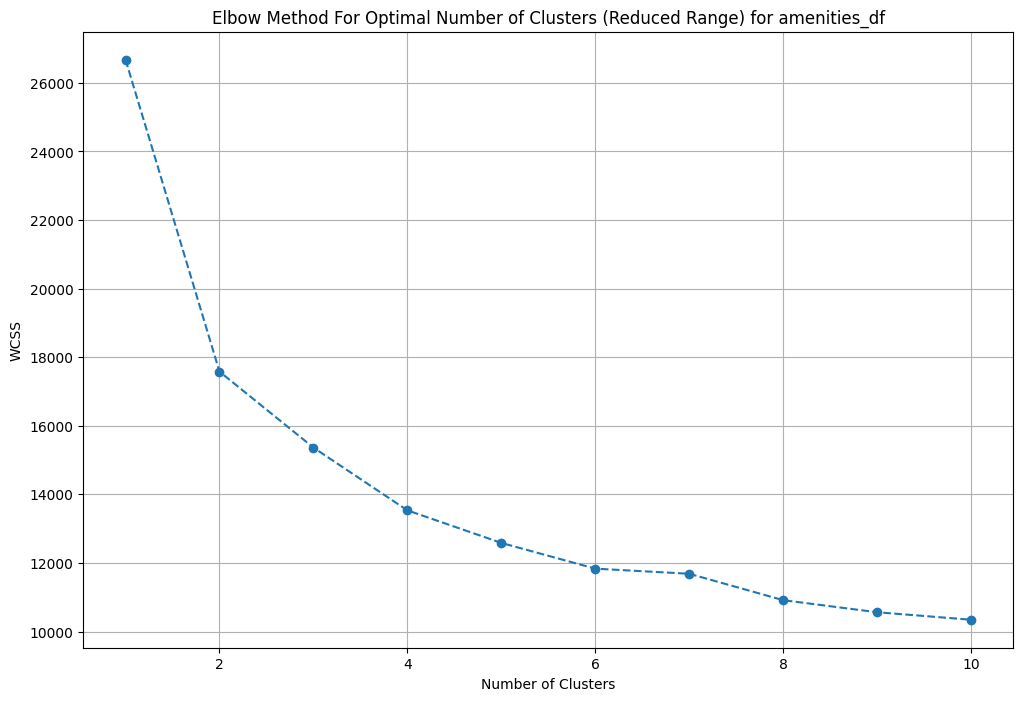

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range) for amenities_df')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()



## number of categories to be classify the flat or house on the basis of the ameities  = 2

## 2 catogories only , might indicate the failure of the algorithm to make separate clusters


# thus instaed of categories , a score will be given to each property , also each amenity will be assigned a feature importance for better clarity in scoring

## scoring will be done on the luxury factor .

# highest score : golf course , lawn tennis court
# lowest : street lights , milk booth , water supply

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,not available,2.0,NaN,New Property,"['Sector 55-56 Metro Station', 'The Leaf Mall Sohna', 'Omaxe Gurgaon Mall', 'Badshahpur Sohna Rd Hwy', 'Vidya Niketan School', 'KIIT College of Engg', 'Scottish High International School', 'Rawal Institutions', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Spaze Business Park', 'DLF Cyber City']",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0,0,"[Lift(s), Park]"
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,New Property,"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,1103.0,1,1,0,0,0,0,"[Power Back-up, Intercom Facility, Lift(s), Swimming Pool, Park, Piped-gas, Internet/wi-fi connectivity, Fitness Centre / GYM, Club house / Community Center]"
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road', 'Dwarka Expy', 'RPS International School', 'SGT University', 'Shree Radhey Hospital And Trauma Center', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0,1,"[Intercom Facility, Lift(s), Park]"
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,not available,17.0,NaN,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,1000.0,585.0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]"
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,"servant room,others",10.0,North-West,Relatively New,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-8, Imt Manesar', 'Western Peripheral Expressway', 'RPS International School Sector 89', 'DPG Institute of Technology', 'Aarvy Healthcare Hospital', 'Indira Gandhi International Airport', 'Holiday Inn Sector 90', 'De Adventure Park', 'National Tennis Academy Sector 98']","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '15 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Hei

In [ ]:
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
luxury_score = amenities_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)
df['luxury_score'] = luxury_score

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,not available,2.0,NaN,New Property,"['Sector 55-56 Metro Station', 'The Leaf Mall Sohna', 'Omaxe Gurgaon Mall', 'Badshahpur Sohna Rd Hwy', 'Vidya Niketan School', 'KIIT College of Engg', 'Scottish High International School', 'Rawal Institutions', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Spaze Business Park', 'DLF Cyber City']",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0,0,"[Lift(s), Park]",8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,New Property,"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,1103.0,1,1,0,0,0,0,"[Power Back-up, Intercom Facility, Lift(s), Swimming Pool, Park, Piped-gas, Internet/wi-fi connectivity, Fitness Centre / GYM, Club house / Community Center]",38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road', 'Dwarka Expy', 'RPS International School', 'SGT University', 'Shree Radhey Hospital And Trauma Center', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0,1,"[Intercom Facility, Lift(s), Park]",15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,not available,17.0,NaN,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,1000.0,585.0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,"servant room,others",10.0,North-West,Relatively New,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-8, Imt Manesar', 'Western Peripheral Expressway', 'RPS International School Sector 89', 'DPG Institute of Technology', 'Aarvy Healthcare Hospital', 'Indira Gandhi International Airport', 'Holiday Inn Sector 90', 'De Adventure Park', 'National Tennis Academy Sector 98']","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '15 Light', '5 AC', '1 Chimney', '4 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lif

Since the features are extracted from the exisiting ones drop the original  columns

In [ ]:
df = df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'])

In [ ]:
df.shape

(3803, 23)

In [ ]:
from google.colab import files
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)
files.download('gurgaon_properties_cleaned_v2.csv')